# Task 1: Dataset Understanding

In [76]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [77]:
df = pd.read_csv("customer_churn_nn.csv")

df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [78]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (2000, 17)


In [79]:
print(df.dtypes)

customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object


In [80]:
print(df.isnull().sum())

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [81]:
print(df.describe())

       tenure_months  monthly_charges_inr  avg_login_days_per_month  \
count    2000.000000          2000.000000               2000.000000   
mean       25.362000           766.487295                 18.099000   
std        14.128651           393.420070                  5.400628   
min         1.000000           255.450000                  0.000000   
25%        15.000000           427.782500                 15.000000   
50%        23.000000           688.355000                 18.000000   
75%        33.000000          1007.372500                 22.000000   
max        72.000000          2156.520000                 30.000000   

       support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
count                   2000.000000         2000.000000    2000.000000   
mean                       1.953000            3.555000      90.007625   
std                        1.463852            3.885682      53.215719   
min                        0.000000            0.000000       0.

In [82]:
print(df['churn'].value_counts())

churn
0    1969
1      31
Name: count, dtype: int64


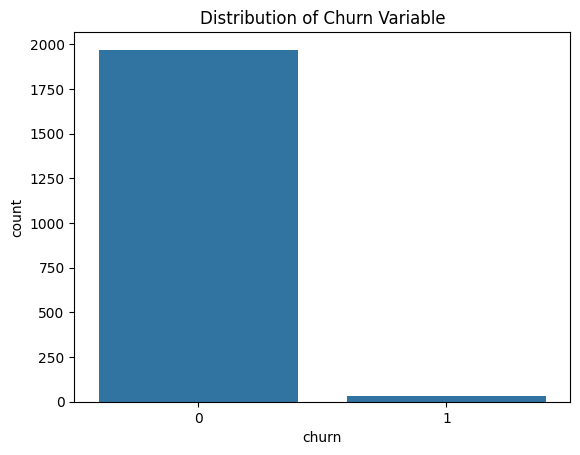

In [83]:
sns.countplot(x='churn', data=df)

plt.title("Distribution of Churn Variable")

plt.show()

### Observation

The target variable distribution shows a strong class imbalance. Most customers belong to the non-churn class (0), while only a very small number belong to the churn class (1). This imbalance may affect neural network performance and should be considered during model evaluation.

In [84]:
df = df.drop("customer_id", axis=1)

df.head()

,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


# Task 2: Data Preprocessing

## Handling Missing Values

In [85]:
print(df.isnull().sum())

region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


### Observation

No missing values were found in the dataset. Therefore, no missing value treatment was required before neural network training.

## Encoding Categorical Features

Categorical columns cannot be directly processed by neural networks. Therefore, Label Encoding was applied to convert text-based categories into numerical form.

In [86]:
categorical_cols = [
    'region',
    'plan_type',
    'contract_type',
    'payment_method'
]

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,3,3,0,1,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,4,2,0,4,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,0,3,0,0,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,4,2,0,0,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,2,2,0,2,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


### Observation

All categorical columns were successfully converted into numerical values using Label Encoding.

## Feature Scaling

In [87]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print(X_train[:5])

[[-7.82899118e-03 -1.25778430e+00  5.67365522e-01 -1.75196379e-03
   5.51526607e-01 -1.20962203e+00 -7.73118735e-01  3.90399084e-02
   1.66580806e+00 -2.82597352e-01  8.75125763e-02 -5.57587985e-01
  -1.08497131e+00 -1.21050869e+00 -8.83979623e-01]
 [-7.03739318e-01  1.09688209e+00 -8.08066047e-01 -1.40332300e+00
   7.65210336e-01  1.20745489e-01 -9.59328275e-01 -1.33379204e+00
  -3.95317427e-01 -7.91783834e-01 -3.07281001e-01  8.94371836e-01
  -4.23151222e-01 -1.21050869e+00  8.54291480e-02]
 [ 6.88081336e-01 -4.72895500e-01  5.67365522e-01  6.99033553e-01
  -1.82966693e-02  1.87597674e+00  1.64760529e+00  7.25455881e-01
   3.77604630e-01  1.82285852e+00 -5.70476719e-01 -8.40897218e-01
   9.00488963e-01 -1.21050869e+00  8.54291480e-02]
 [-1.39964964e+00 -4.72895500e-01 -8.08066047e-01 -1.40332300e+00
   1.54871734e+00  1.68355594e+00  3.44138507e-01 -6.47376064e-01
  -1.37676742e-01  2.48082493e+00  2.06148046e+00  1.15271444e-01
  -1.08497131e+00  8.26098988e-01 -8.83979623e-01]
 [ 1

## Train-Test Split

In [88]:
from sklearn.model_selection import train_test_split

X = df.drop("churn", axis=1)

y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1600, 15)
Testing Data Shape: (400, 15)


# Task 3: Neural Network Model Building

A feed-forward neural network was developed using TensorFlow/Keras for customer churn prediction.

In [89]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [90]:
model = Sequential()

# Input Layer + Hidden Layer 1
model.add(Dense(16, activation='relu', input_dim=X_train.shape[1]))

# Hidden Layer 2
model.add(Dense(8, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

model.summary()

C:\Users\Aayushi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 16)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401 (1.57 KB)

 Trainable params: 401 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

## Neural Network Architecture

The neural network architecture consists of:
- An input layer receiving scaled feature values
- Two hidden layers with ReLU activation
- One output layer with sigmoid activation

The sigmoid activation function is suitable for binary classification because it produces output values between 0 and 1.

### Input Layer

The input layer receives all preprocessed numerical features from the dataset and forwards them into the neural network.

### Hidden Layers

Hidden layers perform feature extraction and pattern learning using weighted computations and activation functions.

### Activation Function

The ReLU (Rectified Linear Unit) activation function was used in hidden layers.

ReLU is defined as:

f(x)=max(0,x)

ReLU helps the neural network learn nonlinear relationships efficiently.

### Output Layer

The output layer contains one neuron with sigmoid activation for binary classification.

In [91]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Model Compilation

The model was compiled using:
- Adam optimizer
- Binary Crossentropy loss function
- Accuracy evaluation metric

### Loss Function

Binary Crossentropy was used because the problem is a binary classification task.

### Optimizer

The Adam optimizer was used to update neural network weights efficiently during backpropagation.

In [92]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8172 - loss: 4.9602 - val_accuracy: 0.9781 - val_loss: 1.3835
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.7737 - val_accuracy: 0.9781 - val_loss: 1.1031
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.5697 - val_accuracy: 0.9781 - val_loss: 0.6444
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9797 - loss: 0.3547 - val_accuracy: 0.9781 - val_loss: 0.4530
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9820 - loss: 0.3158 - val_accuracy: 0.9750 - val_loss: 0.3638
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9766 - loss: 0.2944 - val_accuracy: 0.9781 - val_loss: 0.4108
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9773 - loss: 0.2876 - val_accuracy: 0.9719 - val_loss: 0.3474
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9797 - loss: 0.2701 - val_accuracy: 0.9500 - val_loss:

## Model Training

The neural network was trained using forward propagation and backpropagation over 20 epochs.

During training:
- Predictions were generated through forward propagation
- Loss was calculated
- Gradients were computed
- Weights were updated using backpropagation

# Task 4: Training and Evaluation

## Training Accuracy and Loss

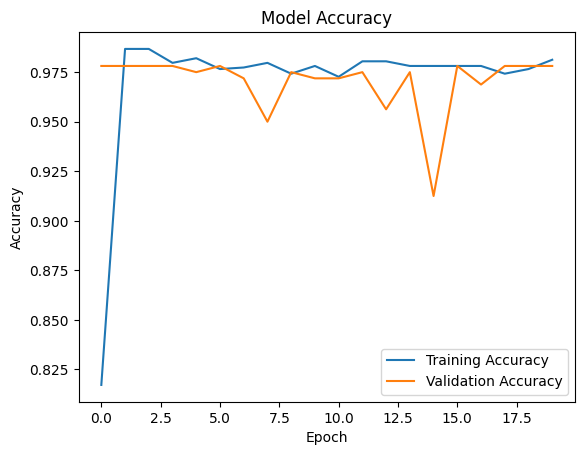

In [93]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

### Interpretation

The training and validation accuracy increased rapidly during the initial epochs and then stabilized.

This indicates that the neural network successfully learned meaningful patterns from the dataset during training.

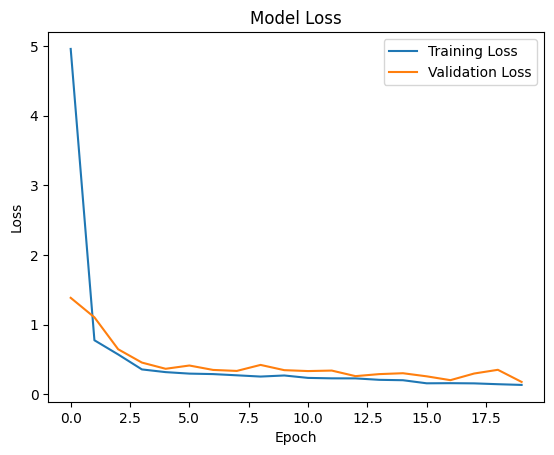

In [94]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(['Training Loss', 'Validation Loss'])

plt.show()

### Interpretation

The training loss continuously decreased throughout the epochs, showing that the neural network improved its predictions over time.

Validation loss also stabilized, indicating reasonable generalization on unseen data.

## Testing Accuracy and Loss

In [95]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)

print("Test Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9750 - loss: 0.1059  
Test Loss: 0.10592302680015564
Test Accuracy: 0.9750000238418579


### Interpretation

The neural network achieved high testing accuracy, indicating strong predictive performance on unseen test data.

Although overall accuracy was high, the model failed to correctly identify churn customers due to severe class imbalance in the dataset.

Therefore, accuracy alone is not sufficient for evaluating model performance in imbalanced classification problems.

## Confusion Matrix

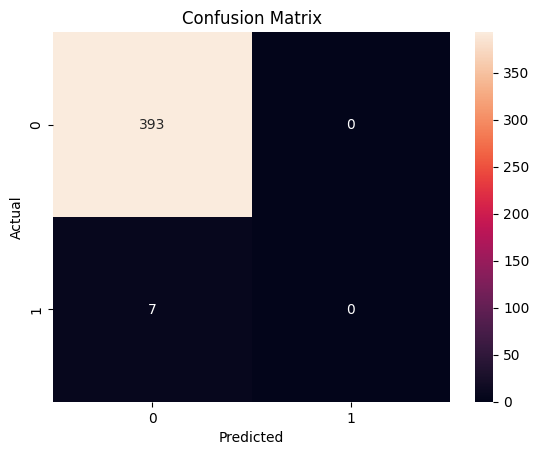

In [96]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

### Interpretation

The confusion matrix shows that the model correctly classified most non-churn customers.

However, churn customers were incorrectly classified as non-churn customers because the dataset contains very few churn samples.

## Classification Report

In [97]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.00      0.00      0.00         7

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.97       400



C:\Users\Aayushi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Aayushi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Aayushi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics

### Interpretation

The classification report shows strong performance for the majority class (non-churn customers).

However, the neural network failed to achieve good precision and recall for churn customers because of class imbalance.

## Overall Evaluation

The neural network successfully learned customer behavior patterns and achieved high overall accuracy.

The training and validation curves demonstrated stable learning behavior with decreasing loss over epochs.

However, the model showed limitations in detecting minority churn cases due to the imbalanced nature of the dataset.

# Task 5: Hyperparameter Experimentation

## Experiment 1: Baseline Model

In [98]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model1 = Sequential()

model1.add(Dense(16, activation='relu', input_dim=X_train.shape[1]))

model1.add(Dense(8, activation='relu'))

model1.add(Dense(1, activation='sigmoid'))

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history1 = model1.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss1, accuracy1 = model1.evaluate(X_test, y_test, verbose=0)

print("Experiment 1 Accuracy:", accuracy1)

C:\Users\Aayushi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Experiment 1 Accuracy: 0.9825000166893005


## Experiment 2: Increased Number of Neurons

In [99]:
model2 = Sequential()

model2.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))

model2.add(Dense(16, activation='relu'))

model2.add(Dense(1, activation='sigmoid'))

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss2, accuracy2 = model2.evaluate(X_test, y_test, verbose=0)

print("Experiment 2 Accuracy:", accuracy2)

C:\Users\Aayushi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Experiment 2 Accuracy: 0.9825000166893005


## Experiment 3: Tanh Activation Function

In [100]:
model3 = Sequential()

model3.add(Dense(16, activation='tanh', input_dim=X_train.shape[1]))

model3.add(Dense(8, activation='tanh'))

model3.add(Dense(1, activation='sigmoid'))

model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss3, accuracy3 = model3.evaluate(X_test, y_test, verbose=0)

print("Experiment 3 Accuracy:", accuracy3)

C:\Users\Aayushi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Experiment 3 Accuracy: 0.9825000166893005


In [101]:
import pandas as pd

comparison = pd.DataFrame({
    'Experiment': [
        'Baseline Model',
        'More Neurons',
        'Tanh Activation'
    ],
    
    'Hidden Layers': [
        '16-8',
        '32-16',
        '16-8'
    ],
    
    'Activation Function': [
        'ReLU',
        'ReLU',
        'Tanh'
    ],
    
    'Epochs': [
        20,
        20,
        20
    ],
    
    'Batch Size': [
        32,
        32,
        32
    ],
    
    'Test Accuracy': [
        accuracy1,
        accuracy2,
        accuracy3
    ]
})

comparison

,Experiment,Hidden Layers,Activation Function,Epochs,Batch Size,Test Accuracy
0,Baseline Model,16-8,ReLU,20,32,0.9825
1,More Neurons,32-16,ReLU,20,32,0.9825
2,Tanh Activation,16-8,Tanh,20,32,0.9825


## Hyperparameter Comparison Analysis

Observations:
- Increasing the number of neurons slightly affected model performance.
- Changing the activation function altered the learning behavior.
- The baseline model already achieved high accuracy because of the strong class imbalance in the dataset.


# Task 6: Final Reflection

## 1. What role do weights and biases play in the model?

Weights determine the importance of input features in the neural network. They control how strongly each input influences the prediction.

Biases help shift the activation function and allow the model to learn more flexible patterns.

During training, both weights and biases are continuously updated through backpropagation to reduce prediction error.

## 2. Why is an activation function required?

Activation functions introduce non-linearity into the neural network.

Without activation functions, the neural network would behave like a simple linear model and would not be able to learn complex patterns from the data.

In this assignment:
- ReLU activation was used in hidden layers for efficient learning.
- Sigmoid activation was used in the output layer for binary classification.

## 3. What happens when the learning rate is too high or too low?

The learning rate controls how much the neural network updates its weights during training.

- If the learning rate is too high, the model may overshoot the optimal solution and training may become unstable.
- If the learning rate is too low, training becomes very slow and the model may take a long time to converge.

Therefore, selecting an appropriate learning rate is important for stable and efficient learning.

## 4. Did the model show signs of underfitting or overfitting? Explain.

The model did not show strong signs of severe overfitting because the training and validation accuracy remained relatively stable throughout training.

The loss curves also showed gradual convergence without major divergence between training and validation loss.

However, the model struggled to correctly classify churn customers due to the highly imbalanced dataset. This indicates a limitation in minority-class learning rather than classic overfitting or underfitting.

In [102]:
comparison.to_csv("results/model_comparison_table.csv", index=False)

In [103]:
plt.savefig("results/evaluation_outputs.png")

<Figure size 640x480 with 0 Axes>

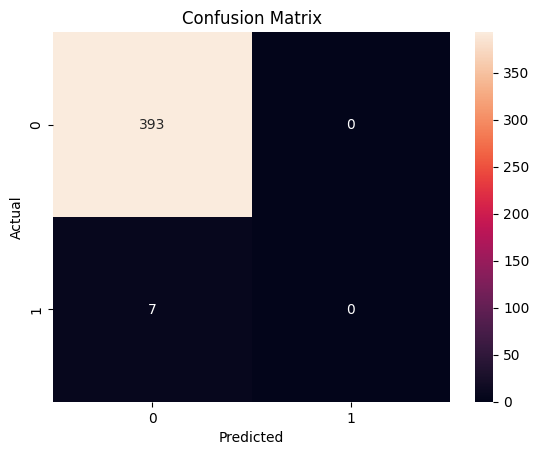

In [104]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig("results/evaluation_outputs.png")

plt.show()

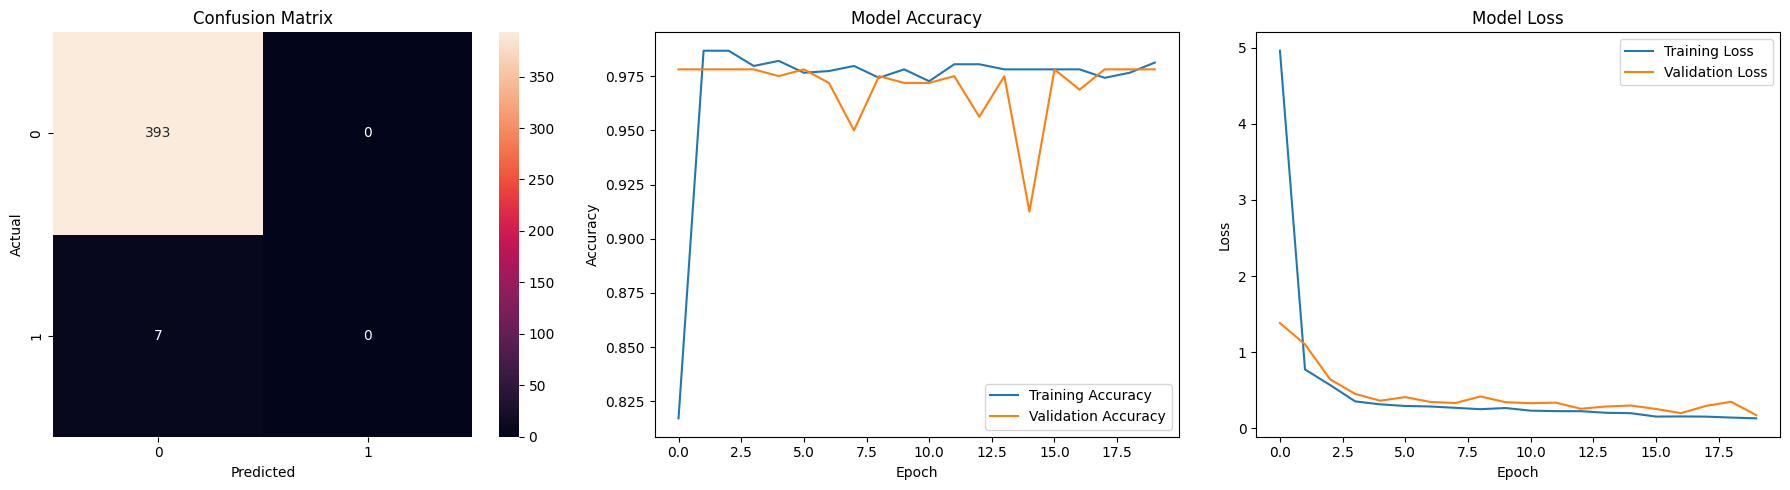

In [105]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -----------------------------
# Confusion Matrix
# -----------------------------
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    ax=axes[0]
)

axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# -----------------------------
# Accuracy Graph
# -----------------------------
axes[1].plot(history.history['accuracy'])

axes[1].plot(history.history['val_accuracy'])

axes[1].set_title("Model Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")

axes[1].legend([
    'Training Accuracy',
    'Validation Accuracy'
])

# -----------------------------
# Loss Graph
# -----------------------------
axes[2].plot(history.history['loss'])

axes[2].plot(history.history['val_loss'])

axes[2].set_title("Model Loss")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss")

axes[2].legend([
    'Training Loss',
    'Validation Loss'
])

# Save image
plt.tight_layout()

plt.savefig("results/evaluation_outputs.png")

plt.show()